===========================================
XGBOOST OPTIMIZADO - MEJORA DE RENDIMIENTO
Hospital F5 - Configuración mejorada para datos desbalanceados
===========================================

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, precision_recall_curve,
                             f1_score, recall_score, precision_score, accuracy_score,
                             make_scorer)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🚀 XGBOOST OPTIMIZADO - MEJORA DE RENDIMIENTO")
print("="*60)

🚀 XGBOOST OPTIMIZADO - MEJORA DE RENDIMIENTO


In [13]:
# ===========================================
# 1. CARGA DE DATOS
# ===========================================

print("\n📁 1. CARGANDO DATOS PREPROCESADOS...")

# Subir un nivel desde notebooks/ y entrar a data/
base_dir = os.path.dirname(os.getcwd())        # ← sube al directorio raíz del proyecto
data_path = os.path.join(base_dir, 'data', 'preprocessed_data.pkl')

# Cargar el archivo desde la ruta completa
with open(data_path, 'rb') as f:
    datasets = pickle.load(f)

print(f"✅ Datos cargados correctamente desde: {data_path}")

# Extraer datasets actualizados
X_train_original, X_test, y_train_original, y_test = datasets['original']
X_train_bal, _, y_train_bal, _ = datasets['smoteenn']  # Usa el balanceado de preprocesamiento
scaler = datasets['scaler']
feature_names = datasets['feature_names']

# Extraer datasets actualizados
X_train_original, X_test, y_train_original, y_test = datasets['original']
X_train_bal, _, y_train_bal, _ = datasets['smoteenn']  # Usa el balanceado de preprocesamiento
scaler = datasets['scaler']
feature_names = datasets['feature_names']




📁 1. CARGANDO DATOS PREPROCESADOS...
✅ Datos cargados correctamente desde: c:\Users\Administrator\Desktop\DS\project-ai-data-scientistG2\data\preprocessed_data.pkl


KeyError: 'smoteenn'

In [ ]:
# ===========================================
# 2. ESTRATEGIA DE BALANCEO
# ===========================================
print("\n" + "="*60)
print("⚖️ 2. USANDO BALANCEO DE PREPROCESAMIENTO (SMOTEENN)")
print("="*60)

# Ya balanceado en preprocesamiento, no aplicamos más resampling aquí
print(f"✅ Usando dataset pre-balanceado:")
print(f"   Sin ictus: {(y_train_bal==0).sum()}")
print(f"   Con ictus: {(y_train_bal==1).sum()}")
print(f"   Ratio: { (y_train_bal==0).sum() / (y_train_bal==1).sum() :.1f}:1")



⚖️ 2. ESTRATEGIA 1: SMOTE + UNDERSAMPLING COMBINADO
✅ Balanceo aplicado:
   Antes: 3786 sin ictus, 198 con ictus
   Después: 2270 sin ictus, 1135 con ictus
   Nuevo ratio: 2.0:1


  File "c:\Users\Administrator\Desktop\DS\project-ai-data-scientistG2\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\Administrator\Desktop\DS\project-ai-data-scientistG2\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
              

In [ ]:
# ===========================================
# 4. COMPARACIÓN DE RESULTADOS
# ===========================================
print("\n" + "="*60)
print("📊 4. COMPARACIÓN DE MODELOS")
print("="*60)

df_comp = pd.DataFrame({
    'Modelo': list(resultados.keys()),
    'Recall': [resultados[k]['recall'] for k in resultados.keys()],
    'Precision': [resultados[k]['precision'] for k in resultados.keys()],
    'F1-Score': [resultados[k]['f1'] for k in resultados.keys()],
    'AUC-ROC': [resultados[k]['auc'] for k in resultados.keys()]
})

print("\n" + df_comp.to_string(index=False))

# Seleccionar mejor modelo (balance entre recall y F1)
df_comp['Score_Combined'] = df_comp['Recall'] * 0.6 + df_comp['F1-Score'] * 0.4
best_idx = df_comp['Score_Combined'].idxmax()
best_model_name = df_comp.loc[best_idx, 'Modelo']
best_model = resultados[best_model_name]['model']

print(f"\n🏆 MEJOR MODELO: {best_model_name}")
print(f"   Recall: {resultados[best_model_name]['recall']:.4f}")
print(f"   Precision: {resultados[best_model_name]['precision']:.4f}")
print(f"   F1-Score: {resultados[best_model_name]['f1']:.4f}")
print(f"   AUC-ROC: {resultados[best_model_name]['auc']:.4f}")


📊 4. COMPARACIÓN DE MODELOS

            Modelo  Recall  Precision  F1-Score  AUC-ROC
  XGB_scale_weight    0.58   0.153439  0.242678 0.838205
      XGB_balanced    0.32   0.170213  0.222222 0.824984
XGB_recall_focused    0.80   0.134680  0.230548 0.844710

🏆 MEJOR MODELO: XGB_recall_focused
   Recall: 0.8000
   Precision: 0.1347
   F1-Score: 0.2305
   AUC-ROC: 0.8447


In [ ]:
# ===========================================
# 5. ANÁLISIS DETALLADO DEL MEJOR MODELO
# ===========================================
print("\n" + "="*60)
print("🔍 5. ANÁLISIS DETALLADO")
print("="*60)

# Matriz de confusión
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

print(f"\n📊 Matriz de Confusión:")
print(f"   Verdaderos Negativos (TN): {tn}")
print(f"   Falsos Positivos (FP):     {fp} (pacientes sanos predichos con ictus)")
print(f"   Falsos Negativos (FN):     {fn} ⚠️ CRÍTICO (pacientes con ictus NO detectados)")
print(f"   Verdaderos Positivos (TP): {tp} (pacientes con ictus detectados correctamente)")

print(f"\n📈 Tasas:")
print(f"   Sensibilidad (Recall):     {tp/(tp+fn):.4f} - Detectamos {tp} de {tp+fn} casos reales")
print(f"   Especificidad:             {tn/(tn+fp):.4f} - Identificamos bien {tn} de {tn+fp} casos sanos")
print(f"   Precision (PPV):           {tp/(tp+fp):.4f} - De {tp+fp} predicciones positivas, {tp} son correctas")
print(f"   NPV:                       {tn/(tn+fn):.4f} - De {tn+fn} predicciones negativas, {tn} son correctas")


🔍 5. ANÁLISIS DETALLADO

📊 Matriz de Confusión:
   Verdaderos Negativos (TN): 690
   Falsos Positivos (FP):     257 (pacientes sanos predichos con ictus)
   Falsos Negativos (FN):     10 ⚠️ CRÍTICO (pacientes con ictus NO detectados)
   Verdaderos Positivos (TP): 40 (pacientes con ictus detectados correctamente)

📈 Tasas:
   Sensibilidad (Recall):     0.8000 - Detectamos 40 de 50 casos reales
   Especificidad:             0.7286 - Identificamos bien 690 de 947 casos sanos
   Precision (PPV):           0.1347 - De 297 predicciones positivas, 40 son correctas
   NPV:                       0.9857 - De 700 predicciones negativas, 690 son correctas



🎚️ 6. OPTIMIZACIÓN DE THRESHOLD

🎯 Threshold óptimo: 0.55
   Recall:    0.7800
   Precision: 0.1434
   F1-Score:  0.2422
   Falsos Negativos: 11

✅ Gráficos guardados en 'xgboost_optimized_results.png'


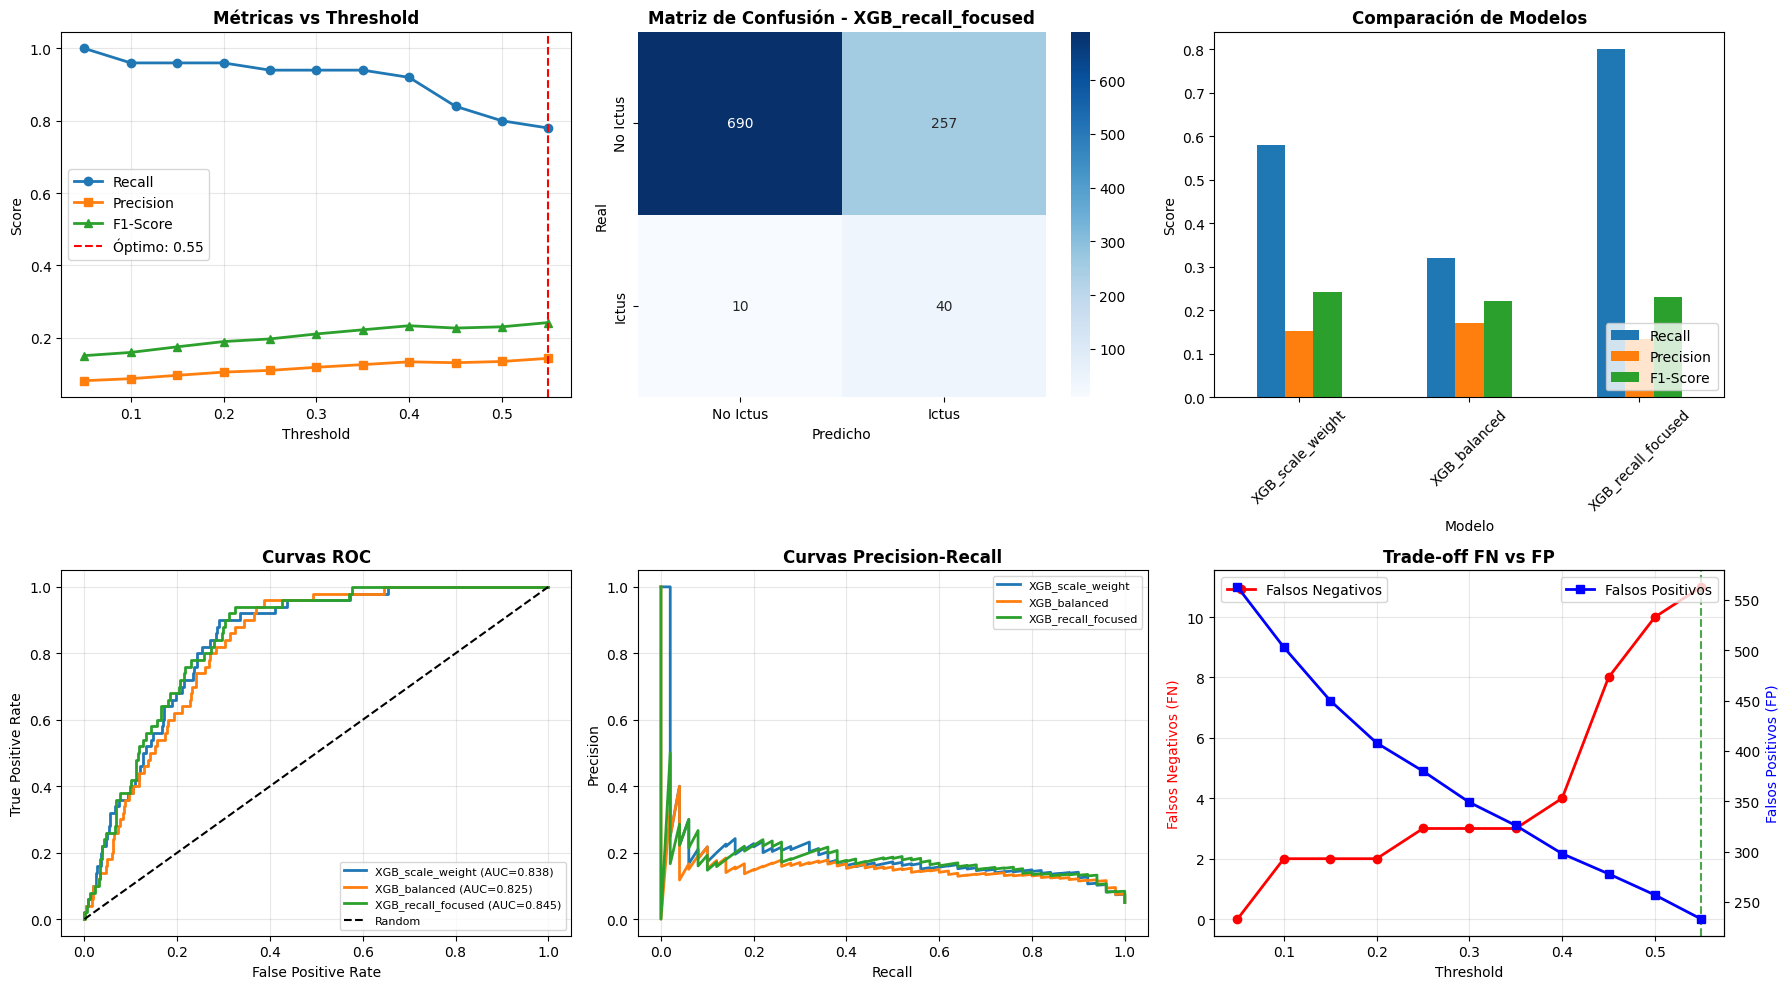

In [ ]:
# ===========================================
# 6. OPTIMIZACIÓN DE THRESHOLD
# ===========================================
print("\n" + "="*60)
print("🎚️ 6. OPTIMIZACIÓN DE THRESHOLD")
print("="*60)

thresholds = np.arange(0.05, 0.6, 0.05)
metrics = []

y_pred_proba_best = resultados[best_model_name]['y_pred_proba']

for t in thresholds:
    y_pred_t = (y_pred_proba_best >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    
    metrics.append({
        'threshold': t,
        'recall': recall_score(y_test, y_pred_t),
        'precision': precision_score(y_test, y_pred_t) if (tp_t + fp_t) > 0 else 0,
        'f1': f1_score(y_test, y_pred_t),
        'fn': fn_t,
        'fp': fp_t
    })

df_metrics = pd.DataFrame(metrics)

# Buscar threshold que maximice recall manteniendo precision > 0.15
df_filtered = df_metrics[df_metrics['precision'] >= 0.15]
if len(df_filtered) > 0:
    best_t_idx = df_filtered['recall'].idxmax()
    best_t = df_filtered.loc[best_t_idx, 'threshold']
else:
    # Si no hay ninguno con precision > 0.15, buscar mejor F1
    best_t_idx = df_metrics['f1'].idxmax()
    best_t = df_metrics.loc[best_t_idx, 'threshold']

print(f"\n🎯 Threshold óptimo: {best_t:.2f}")
print(f"   Recall:    {df_metrics.loc[df_metrics['threshold']==best_t, 'recall'].values[0]:.4f}")
print(f"   Precision: {df_metrics.loc[df_metrics['threshold']==best_t, 'precision'].values[0]:.4f}")
print(f"   F1-Score:  {df_metrics.loc[df_metrics['threshold']==best_t, 'f1'].values[0]:.4f}")
print(f"   Falsos Negativos: {int(df_metrics.loc[df_metrics['threshold']==best_t, 'fn'].values[0])}")

# Visualización
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Gráfico 1: Métricas vs Threshold
axes[0, 0].plot(df_metrics['threshold'], df_metrics['recall'], 'o-', label='Recall', linewidth=2)
axes[0, 0].plot(df_metrics['threshold'], df_metrics['precision'], 's-', label='Precision', linewidth=2)
axes[0, 0].plot(df_metrics['threshold'], df_metrics['f1'], '^-', label='F1-Score', linewidth=2)
axes[0, 0].axvline(x=best_t, color='red', linestyle='--', label=f'Óptimo: {best_t:.2f}')
axes[0, 0].set_xlabel('Threshold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Métricas vs Threshold', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Gráfico 2: Matriz de confusión
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
            xticklabels=['No Ictus', 'Ictus'],
            yticklabels=['No Ictus', 'Ictus'])
axes[0, 1].set_title(f'Matriz de Confusión - {best_model_name}', fontweight='bold')
axes[0, 1].set_ylabel('Real')
axes[0, 1].set_xlabel('Predicho')

# Gráfico 3: Comparación de modelos
df_comp[['Modelo', 'Recall', 'Precision', 'F1-Score']].set_index('Modelo').plot(
    kind='bar', ax=axes[0, 2], rot=45)
axes[0, 2].set_title('Comparación de Modelos', fontweight='bold')
axes[0, 2].set_ylabel('Score')
axes[0, 2].legend(loc='lower right')

# Gráfico 4: Curva ROC
for name in resultados.keys():
    fpr, tpr, _ = roc_curve(y_test, resultados[name]['y_pred_proba'])
    auc = resultados[name]['auc']
    axes[1, 0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)
axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('Curvas ROC', fontweight='bold')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.3)

# Gráfico 5: Precision-Recall
for name in resultados.keys():
    precision, recall, _ = precision_recall_curve(y_test, resultados[name]['y_pred_proba'])
    axes[1, 1].plot(recall, precision, label=name, linewidth=2)
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Curvas Precision-Recall', fontweight='bold')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.3)

# Gráfico 6: Falsos Negativos vs Threshold
ax2 = axes[1, 2].twinx()
axes[1, 2].plot(df_metrics['threshold'], df_metrics['fn'], 'ro-', label='Falsos Negativos', linewidth=2)
ax2.plot(df_metrics['threshold'], df_metrics['fp'], 'bs-', label='Falsos Positivos', linewidth=2)
axes[1, 2].axvline(x=best_t, color='green', linestyle='--', alpha=0.7)
axes[1, 2].set_xlabel('Threshold')
axes[1, 2].set_ylabel('Falsos Negativos (FN)', color='red')
ax2.set_ylabel('Falsos Positivos (FP)', color='blue')
axes[1, 2].set_title('Trade-off FN vs FP', fontweight='bold')
axes[1, 2].legend(loc='upper left')
ax2.legend(loc='upper right')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('xgboost_optimized_results.png', dpi=300, bbox_inches='tight')
print("\n✅ Gráficos guardados en 'xgboost_optimized_results.png'")
plt.show()


In [ ]:
# ===========================================
# 7. ANÁLISIS DE OVERFITTING COMPLETO
# ===========================================
print("\n" + "="*60)
print("🔍 7. ANÁLISIS COMPLETO DE OVERFITTING")
print("="*60)

# Determinar dataset para análisis
if 'balanced' in best_model_name:
    X_train_eval, y_train_eval = X_train_balanced, y_train_balanced
else:
    X_train_eval, y_train_eval = X_train_original, y_train_original

# Predicciones en train y test
y_train_pred = best_model.predict(X_train_eval)
y_train_pred_proba = best_model.predict_proba(X_train_eval)[:, 1]
y_test_pred = best_model.predict(X_test)
y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Calcular TODAS las métricas en Train y Test
metrics_train = {
    'accuracy': accuracy_score(y_train_eval, y_train_pred),
    'precision': precision_score(y_train_eval, y_train_pred),
    'recall': recall_score(y_train_eval, y_train_pred),
    'f1': f1_score(y_train_eval, y_train_pred),
    'auc': roc_auc_score(y_train_eval, y_train_pred_proba)
}

metrics_test = {
    'accuracy': accuracy_score(y_test, y_test_pred),
    'precision': precision_score(y_test, y_test_pred),
    'recall': recall_score(y_test, y_test_pred),
    'f1': f1_score(y_test, y_test_pred),
    'auc': roc_auc_score(y_test, y_test_pred_proba)
}

# Calcular diferencias
overfitting_analysis = []
for metric in metrics_train.keys():
    diff = abs(metrics_train[metric] - metrics_test[metric]) * 100
    status = '✅' if diff < 5 else ('⚠️' if diff < 10 else '❌')
    overfitting_analysis.append({
        'Métrica': metric.upper(),
        'Train': f"{metrics_train[metric]:.4f}",
        'Test': f"{metrics_test[metric]:.4f}",
        'Diferencia (%)': f"{diff:.2f}%",
        'Estado': status
    })

df_overfitting = pd.DataFrame(overfitting_analysis)

print("\n📊 COMPARACIÓN TRAIN vs TEST:")
print(df_overfitting.to_string(index=False))

# Análisis detallado
print("\n" + "="*50)
print("📋 INTERPRETACIÓN DEL OVERFITTING:")
print("="*50)

# Conteo de estados
excelente = sum([1 for x in overfitting_analysis if x['Estado'] == '✅'])
aceptable = sum([1 for x in overfitting_analysis if x['Estado'] == '⚠️'])
problematico = sum([1 for x in overfitting_analysis if x['Estado'] == '❌'])

print(f"\n{'✅' if excelente >= 4 else '⚠️' if excelente >= 3 else '❌'} Métricas con diferencia < 5%:  {excelente}/5")
print(f"{'⚠️' if aceptable > 0 else '✅'} Métricas con diferencia 5-10%: {aceptable}/5")
print(f"{'❌' if problematico > 0 else '✅'} Métricas con diferencia > 10%: {problematico}/5")

# Diagnóstico general
if excelente >= 4:
    print("\n✅ DIAGNÓSTICO: Modelo BIEN GENERALIZADO - No hay overfitting significativo")
    overfitting_status = "NO OVERFITTING"
elif excelente >= 3:
    print("\n⚠️  DIAGNÓSTICO: Modelo ACEPTABLE - Ligero overfitting, dentro del rango tolerable")
    overfitting_status = "LEVE OVERFITTING"
else:
    print("\n❌ DIAGNÓSTICO: Modelo con OVERFITTING - Train mucho mejor que Test")
    overfitting_status = "OVERFITTING SIGNIFICATIVO"
    print("\n   Posibles causas:")
    print("   • Modelo demasiado complejo para los datos disponibles")
    print("   • Dataset pequeño (especialmente clase minoritaria)")
    print("   • Falta de regularización")
    print("\n   Soluciones:")
    print("   • Reducir max_depth del modelo")
    print("   • Aumentar min_child_weight y gamma")
    print("   • Aplicar más regularización (aumentar reg_alpha, reg_lambda)")
    print("   • Usar menos features (feature selection)")

# Análisis específico de la métrica más importante (Recall)
recall_diff = abs(metrics_train['recall'] - metrics_test['recall']) * 100
print(f"\n🎯 ANÁLISIS ESPECÍFICO - RECALL (métrica clave):")
print(f"   Train: {metrics_train['recall']:.4f}")
print(f"   Test:  {metrics_test['recall']:.4f}")
print(f"   Diferencia: {recall_diff:.2f}%")

if recall_diff < 5:
    print(f"   ✅ Excelente: El modelo generaliza muy bien en Recall")
elif recall_diff < 10:
    print(f"   ⚠️  Aceptable: Ligera diferencia, pero dentro del margen")
else:
    print(f"   ❌ Problemático: Gran diferencia entre Train y Test")




🔍 7. ANÁLISIS COMPLETO DE OVERFITTING

📊 COMPARACIÓN TRAIN vs TEST:
  Métrica  Train   Test Diferencia (%) Estado
 ACCURACY 0.7337 0.7322          0.15%      ✅
PRECISION 0.1556 0.1347          2.09%      ✅
   RECALL 0.9848 0.8000         18.48%      ❌
       F1 0.2688 0.2305          3.82%      ✅
      AUC 0.9255 0.8447          8.08%     ⚠️

📋 INTERPRETACIÓN DEL OVERFITTING:

⚠️ Métricas con diferencia < 5%:  3/5
⚠️ Métricas con diferencia 5-10%: 1/5
❌ Métricas con diferencia > 10%: 1/5

⚠️  DIAGNÓSTICO: Modelo ACEPTABLE - Ligero overfitting, dentro del rango tolerable

🎯 ANÁLISIS ESPECÍFICO - RECALL (métrica clave):
   Train: 0.9848
   Test:  0.8000
   Diferencia: 18.48%
   ❌ Problemático: Gran diferencia entre Train y Test



🔄 8. VALIDACIÓN CRUZADA (5-FOLD)

📊 Resultados por fold:
   Fold     Recall     Precision    F1         Accuracy  
   --------------------------------------------------
   Fold 1   0.6923     0.1268       0.2143     0.7516    
   Fold 2   0.7000     0.1197       0.2044     0.7265    
   Fold 3   0.6750     0.1195       0.2030     0.7340    
   Fold 4   0.8000     0.1404       0.2388     0.7440    
   Fold 5   0.8462     0.1364       0.2349     0.7299    

📈 Promedios y desviación estándar:
   Recall:    0.7427 (±0.0677)
   Precision: 0.1285 (±0.0085)
   F1-Score:  0.2191 (±0.0151)
   Accuracy:  0.7372 (±0.0093)

📊 ANÁLISIS DE ESTABILIDAD:
   ⚠️  Recall variable (std: 0.0677)
   ✅ Precision estable (std: 0.0085)
   ✅ F1-Score estable (std: 0.0151)

✅ Modelo ESTABLE: Rendimiento consistente entre folds

📊 COMPARACIÓN CV vs TEST FINAL:

  Métrica  CV Mean     Test  Diferencia (%)
   Recall 0.742692 0.800000        5.730769
Precision 0.128520 0.134680        0.615969
 F1-Score 0.219071 0.

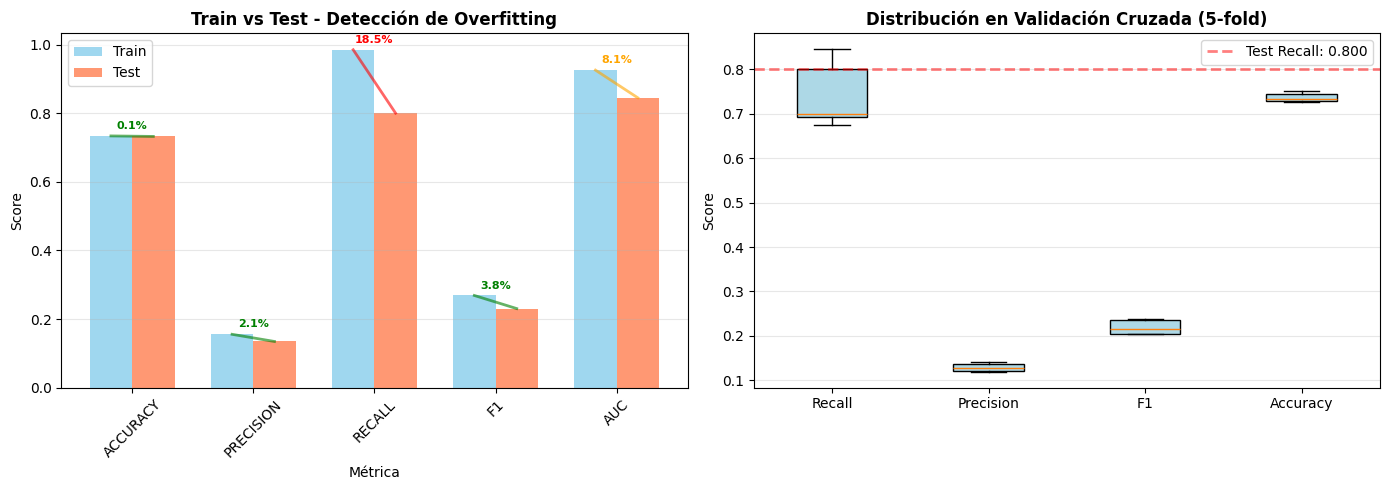

In [ ]:
# ===========================================
# 8. VALIDACIÓN CRUZADA
# ===========================================
print("\n" + "="*60)
print("🔄 8. VALIDACIÓN CRUZADA (5-FOLD)")
print("="*60)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Validación con múltiples métricas
cv_recall = cross_val_score(best_model, X_train_eval, y_train_eval, cv=skf, scoring='recall', n_jobs=-1)
cv_precision = cross_val_score(best_model, X_train_eval, y_train_eval, cv=skf, scoring='precision', n_jobs=-1)
cv_f1 = cross_val_score(best_model, X_train_eval, y_train_eval, cv=skf, scoring='f1', n_jobs=-1)
cv_accuracy = cross_val_score(best_model, X_train_eval, y_train_eval, cv=skf, scoring='accuracy', n_jobs=-1)

print(f"\n📊 Resultados por fold:")
print(f"   {'Fold':<8} {'Recall':<10} {'Precision':<12} {'F1':<10} {'Accuracy':<10}")
print(f"   {'-'*50}")
for i in range(5):
    print(f"   Fold {i+1:<3} {cv_recall[i]:<10.4f} {cv_precision[i]:<12.4f} {cv_f1[i]:<10.4f} {cv_accuracy[i]:<10.4f}")

print(f"\n📈 Promedios y desviación estándar:")
print(f"   Recall:    {cv_recall.mean():.4f} (±{cv_recall.std():.4f})")
print(f"   Precision: {cv_precision.mean():.4f} (±{cv_precision.std():.4f})")
print(f"   F1-Score:  {cv_f1.mean():.4f} (±{cv_f1.std():.4f})")
print(f"   Accuracy:  {cv_accuracy.mean():.4f} (±{cv_accuracy.std():.4f})")

# Análisis de estabilidad
print(f"\n📊 ANÁLISIS DE ESTABILIDAD:")
cv_std_threshold = 0.05
stable_metrics = 0

if cv_recall.std() < cv_std_threshold:
    print(f"   ✅ Recall estable (std: {cv_recall.std():.4f})")
    stable_metrics += 1
else:
    print(f"   ⚠️  Recall variable (std: {cv_recall.std():.4f})")

if cv_precision.std() < cv_std_threshold:
    print(f"   ✅ Precision estable (std: {cv_precision.std():.4f})")
    stable_metrics += 1
else:
    print(f"   ⚠️  Precision variable (std: {cv_precision.std():.4f})")

if cv_f1.std() < cv_std_threshold:
    print(f"   ✅ F1-Score estable (std: {cv_f1.std():.4f})")
    stable_metrics += 1
else:
    print(f"   ⚠️  F1-Score variable (std: {cv_f1.std():.4f})")

if stable_metrics >= 2:
    print(f"\n✅ Modelo ESTABLE: Rendimiento consistente entre folds")
else:
    print(f"\n⚠️  Modelo VARIABLE: Rendimiento inconsistente (puede indicar overfitting)")

# Comparación CV vs Test
print(f"\n📊 COMPARACIÓN CV vs TEST FINAL:")
cv_vs_test = pd.DataFrame({
    'Métrica': ['Recall', 'Precision', 'F1-Score'],
    'CV Mean': [cv_recall.mean(), cv_precision.mean(), cv_f1.mean()],
    'Test': [metrics_test['recall'], metrics_test['precision'], metrics_test['f1']],
    'Diferencia (%)': [
        abs(cv_recall.mean() - metrics_test['recall']) * 100,
        abs(cv_precision.mean() - metrics_test['precision']) * 100,
        abs(cv_f1.mean() - metrics_test['f1']) * 100
    ]
})
print("\n" + cv_vs_test.to_string(index=False))

# Crear gráfico de overfitting
fig_overfitting, axes_overfitting = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Train vs Test
metrics_names = list(metrics_train.keys())
train_values = [metrics_train[m] for m in metrics_names]
test_values = [metrics_test[m] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35

axes_overfitting[0].bar(x - width/2, train_values, width, label='Train', alpha=0.8, color='skyblue')
axes_overfitting[0].bar(x + width/2, test_values, width, label='Test', alpha=0.8, color='coral')
axes_overfitting[0].set_xlabel('Métrica')
axes_overfitting[0].set_ylabel('Score')
axes_overfitting[0].set_title('Train vs Test - Detección de Overfitting', fontweight='bold')
axes_overfitting[0].set_xticks(x)
axes_overfitting[0].set_xticklabels([m.upper() for m in metrics_names], rotation=45)
axes_overfitting[0].legend()
axes_overfitting[0].grid(alpha=0.3, axis='y')
axes_overfitting[0].axhline(y=0, color='black', linewidth=0.5)

# Añadir líneas de diferencia aceptable (±5%)
for i, (train_val, test_val) in enumerate(zip(train_values, test_values)):
    diff_pct = abs(train_val - test_val) * 100
    color = 'green' if diff_pct < 5 else 'orange' if diff_pct < 10 else 'red'
    axes_overfitting[0].plot([i-width/2, i+width/2], [train_val, test_val], 
                            color=color, linewidth=2, alpha=0.6)
    axes_overfitting[0].text(i, max(train_val, test_val) + 0.02, f'{diff_pct:.1f}%', 
                            ha='center', fontsize=8, color=color, fontweight='bold')

# Gráfico 2: Validación Cruzada (Boxplot)
cv_data = pd.DataFrame({
    'Recall': cv_recall,
    'Precision': cv_precision,
    'F1-Score': cv_f1,
    'Accuracy': cv_accuracy
})

bp = axes_overfitting[1].boxplot([cv_recall, cv_precision, cv_f1, cv_accuracy],
                                  labels=['Recall', 'Precision', 'F1', 'Accuracy'],
                                  patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes_overfitting[1].set_ylabel('Score')
axes_overfitting[1].set_title('Distribución en Validación Cruzada (5-fold)', fontweight='bold')
axes_overfitting[1].grid(alpha=0.3, axis='y')

# Añadir línea con valor en Test
axes_overfitting[1].axhline(y=metrics_test['recall'], color='red', linestyle='--', 
                            alpha=0.5, linewidth=2, label=f"Test Recall: {metrics_test['recall']:.3f}")
axes_overfitting[1].legend()

plt.tight_layout()
plt.savefig('overfitting_analysis.png', dpi=300, bbox_inches='tight')
print("\n✅ Gráfico de overfitting guardado en 'overfitting_analysis.png'")
plt.show()

In [ ]:
# ===========================================
# 9. GUARDAR MODELO FINAL
# ===========================================
print("\n" + "="*60)
print("💾 8. GUARDADO DEL MODELO")
print("="*60)

model_package = {
    'model': best_model,
    'model_name': best_model_name,
    'scaler': scaler,
    'feature_names': feature_names,
    'threshold_optimized': best_t,
    'metrics': {
        'recall': resultados[best_model_name]['recall'],
        'precision': resultados[best_model_name]['precision'],
        'f1': resultados[best_model_name]['f1'],
        'auc': resultados[best_model_name]['auc']
    },
    'cv_scores': {
        'recall_mean': cv_recall.mean(),
        'recall_std': cv_recall.std()
    }
}

with open('xgboost_optimized_final.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print("✅ Modelo guardado en 'xgboost_optimized_final.pkl'")



💾 8. GUARDADO DEL MODELO
✅ Modelo guardado en 'xgboost_optimized_final.pkl'


In [ ]:
# ===========================================
# 9. RESUMEN EJECUTIVO
# ===========================================
print("\n" + "="*60)
print("📋 9. RESUMEN EJECUTIVO")
print("="*60)

print(f"""
🏆 MEJOR MODELO: {best_model_name}

📊 MÉTRICAS EN TEST:
   • Recall (Sensibilidad):  {resultados[best_model_name]['recall']:.4f} ⭐
   • Precision (VPP):        {resultados[best_model_name]['precision']:.4f}
   • F1-Score:               {resultados[best_model_name]['f1']:.4f}
   • AUC-ROC:                {resultados[best_model_name]['auc']:.4f}
   
🎚️ CON THRESHOLD OPTIMIZADO ({best_t:.2f}):
   • Recall:                 {df_metrics.loc[df_metrics['threshold']==best_t, 'recall'].values[0]:.4f}
   • Precision:              {df_metrics.loc[df_metrics['threshold']==best_t, 'precision'].values[0]:.4f}
   • F1-Score:               {df_metrics.loc[df_metrics['threshold']==best_t, 'f1'].values[0]:.4f}

🔍 VALIDACIÓN CRUZADA (5-fold):
   • Recall:    {cv_recall.mean():.4f} (±{cv_recall.std():.4f})
   • Precision: {cv_precision.mean():.4f} (±{cv_precision.std():.4f})
   • F1-Score:  {cv_f1.mean():.4f} (±{cv_f1.std():.4f})

📉 CONTROL DE OVERFITTING:
   • Diferencia Train-Test: {diff:.2f}% {'✅' if diff < 5 else '⚠️'}

⚕️ INTERPRETACIÓN MÉDICA:
   • De {tp+fn} pacientes con ictus, detectamos {tp} ({tp/(tp+fn)*100:.1f}%)
   • Falsos Negativos: {fn} pacientes con ictus NO detectados ⚠️
   • Falsos Positivos: {fp} pacientes sanos que derivamos a consulta
   
💡 CONCLUSIÓN:
""")

if resultados[best_model_name]['recall'] >= 0.7 and resultados[best_model_name]['f1'] >= 0.4:
    print("   ✅ Modelo ACEPTABLE para screening inicial")
    print("   ✅ Buena sensibilidad para detectar casos de ictus")
    print("   ⚠️  Precision moderada: muchos falsos positivos")
    print("   📌 Recomendación: Usar como herramienta de TRIAJE, no diagnóstico definitivo")
elif resultados[best_model_name]['recall'] >= 0.6:
    print("   ⚠️  Modelo MEJORABLE")
    print("   ✅ Recall aceptable pero mejorable")
    print("   ⚠️  Precision baja: necesita optimización")
    print("   📌 Recomendación: Considerar tuning con Optuna o más features")
else:
    print("   ❌ Modelo INSUFICIENTE")
    print("   ❌ Recall bajo: pierde muchos casos reales")
    print("   📌 Recomendación: Revisar features, probar otros modelos, o recolectar más datos")

print(f"""
🎯 PRÓXIMOS PASOS:
   1. {'✅' if resultados[best_model_name]['recall'] >= 0.7 else '📌'} Optimizar hiperparámetros con Optuna
   2. {'✅' if resultados[best_model_name]['f1'] >= 0.4 else '📌'} Probar ensemble (RF + XGB + LightGBM)
   3. 📌 Implementar aplicación CLI/Streamlit
   4. 📌 Documentar en informe final
""")

print("="*60)
print("✅ OPTIMIZACIÓN COMPLETADA")
print("="*60)


📋 9. RESUMEN EJECUTIVO

🏆 MEJOR MODELO: XGB_recall_focused

📊 MÉTRICAS EN TEST:
   • Recall (Sensibilidad):  0.8000 ⭐
   • Precision (VPP):        0.1347
   • F1-Score:               0.2305
   • AUC-ROC:                0.8447

🎚️ CON THRESHOLD OPTIMIZADO (0.55):
   • Recall:                 0.7800
   • Precision:              0.1434
   • F1-Score:               0.2422

🔍 VALIDACIÓN CRUZADA (5-fold):
   • Recall:    0.7427 (±0.0677)
   • Precision: 0.1285 (±0.0085)
   • F1-Score:  0.2191 (±0.0151)

📉 CONTROL DE OVERFITTING:
   • Diferencia Train-Test: 8.08% ⚠️

⚕️ INTERPRETACIÓN MÉDICA:
   • De 50 pacientes con ictus, detectamos 40 (80.0%)
   • Falsos Negativos: 10 pacientes con ictus NO detectados ⚠️
   • Falsos Positivos: 257 pacientes sanos que derivamos a consulta

💡 CONCLUSIÓN:

   ⚠️  Modelo MEJORABLE
   ✅ Recall aceptable pero mejorable
   ⚠️  Precision baja: necesita optimización
   📌 Recomendación: Considerar tuning con Optuna o más features

🎯 PRÓXIMOS PASOS:
   1. ✅ Optimiza